In [1]:
import tensorflow as tf
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shutil

from tensorflow import keras
from keras import layers
from keras.callbacks import ModelCheckpoint, EarlyStopping
from keras.applications.resnet import preprocess_input
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import confusion_matrix, roc_auc_score, accuracy_score, precision_score, recall_score, f1_score

from google.colab import drive
drive.mount('/content/drive')

BASE_PATH = "/content/drive/MyDrive/CrossValidation/ResnetOPT"
TRAIN_DIR = "/content/drive/MyDrive/kaggle/train"
TEST_DIR = "/content/drive/MyDrive/kaggle/test"

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS = 10
N_SPLITS = 3
SEED = 42
THRESHOLD = 0.5

folders = [
    "models",
    "histories",
    "metrics",
    "plots/training",
    "plots/folds",
    "plots/metrics"
]

for f in folders:
    os.makedirs(os.path.join(BASE_PATH, f), exist_ok=True)

print(BASE_PATH)
print(os.listdir("/content/drive/MyDrive"))
print(os.listdir(BASE_PATH))

class_names = sorted([
    d for d in os.listdir(TRAIN_DIR)
    if os.path.isdir(os.path.join(TRAIN_DIR, d))
])

print("Class names:", class_names)

filepaths = []
labels = []

for idx, class_name in enumerate(class_names):
    class_dir = os.path.join(TRAIN_DIR, class_name)
    files = sorted([
        os.path.join(class_dir, f)
        for f in os.listdir(class_dir)
        if f.lower().endswith((".jpg", ".jpeg", ".png"))
    ])
    filepaths.extend(files)
    labels.extend([idx] * len(files))

filepaths = np.array(filepaths)
labels = np.array(labels)

print("Total images:", len(filepaths))
print("Label distribution:", {class_names[i]: int((labels == i).sum()) for i in range(len(class_names))})

data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.1),
], name="data_augmentation")

Mounted at /content/drive
/content/drive/MyDrive/CrossValidation/ResnetOPT
['Colab Notebooks', 'kaggle', 'results5', 'results10', 'resultsResnetOPT1', 'resultsVgg16DensenetOPT1', 'GradCam', 'materiali tesi vari', 'CrossValidation', 'Sacilotto Greta Tesi Triennaleee.docx']
['models', 'histories', 'metrics', 'plots']
Class names: ['benign', 'malignant']
Total images: 2637
Label distribution: {'benign': 1440, 'malignant': 1197}


In [2]:
#build model
def build_model(model_name):
    if model_name == "resnet":
        base_model = keras.applications.ResNet50(
            weights="imagenet",
            include_top=False,
            input_shape=(224, 224, 3)
        )
    else:
        raise ValueError("This cross-validation code is configured only for 'resnet'.")


    base_model.trainable = True
    for layer in base_model.layers[:-30]:
        layer.trainable = False

    inputs = keras.Input(shape=(224, 224, 3))

    x = base_model(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(128, activation="relu")(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(1, activation="sigmoid")(x)

    model = keras.Model(inputs, outputs)

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-4),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    return model


#dataset funcions
def decode_and_resize(path, label):
    img = tf.io.read_file(path)
    img = tf.image.decode_image(img, channels=3, expand_animations=False)
    img = tf.image.resize(img, IMG_SIZE)
    img = tf.cast(img, tf.float32)
    img = preprocess_input(img)
    label = tf.cast(label, tf.float32)
    return img, label


def augment_data(img, label):
    img = data_augmentation(img, training=True)
    return img, label


def make_dataset(paths, labels, training=False):
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    ds = ds.map(decode_and_resize, num_parallel_calls=tf.data.AUTOTUNE)

    if training:
        ds = ds.shuffle(buffer_size=len(paths), seed=SEED, reshuffle_each_iteration=True)
        ds = ds.map(augment_data, num_parallel_calls=tf.data.AUTOTUNE)

    ds = ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    return ds


#evaluation funcion
def evaluate_model(model, dataset, threshold=0.5):
    y_true = []
    y_pred_prob = []

    for x, y in dataset:
        preds = model(x, training=False).numpy().flatten()
        y_true.extend(y.numpy().flatten())
        y_pred_prob.extend(preds)

    y_true = np.array(y_true).astype(int)
    y_pred_prob = np.array(y_pred_prob)
    y_pred_bin = (y_pred_prob > threshold).astype(int)

    cm = confusion_matrix(y_true, y_pred_bin)
    tn, fp, fn, tp = cm.ravel()

    accuracy = (tp + tn) / (tp + tn + fp + fn)
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    precision = precision_score(y_true, y_pred_bin, zero_division=0)
    f1 = f1_score(y_true, y_pred_bin, zero_division=0)
    auc = roc_auc_score(y_true, y_pred_prob)

    return {
        "accuracy": accuracy,
        "sensitivity": sensitivity,
        "specificity": specificity,
        "precision": precision,
        "f1": f1,
        "auc": auc,
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "tp": int(tp)
    }

In [ ]:
# 3-FOLD CROSS VALIDATION

model_name = "resnet"

skf = StratifiedKFold(
    n_splits=N_SPLITS,
    shuffle=True,
    random_state=SEED
)

history_dict = {}
fold_results = []

for fold, (train_idx, val_idx) in enumerate(skf.split(filepaths, labels), start=1):
    print("\n" + "="*60)
    print(f"Training {model_name} - Fold {fold}/{N_SPLITS}")
    print("="*60)

    tf.keras.backend.clear_session()

    X_train, X_val = filepaths[train_idx], filepaths[val_idx]
    y_train, y_val = labels[train_idx], labels[val_idx]

    print(f"Train samples: {len(X_train)}")
    print(f"Validation samples: {len(X_val)}")

    train_ds_fold = make_dataset(X_train, y_train, training=True)
    val_ds_fold = make_dataset(X_val, y_val, training=False)

    model = build_model(model_name)

    checkpoint_path = os.path.join(BASE_PATH, "models", f"{model_name}_fold{fold}_best.keras")
    history_path = os.path.join(BASE_PATH, "histories", f"{model_name}_fold{fold}_history.json")

    checkpoint = ModelCheckpoint(
        filepath=checkpoint_path,
        monitor="val_loss",
        save_best_only=True,
        mode="min",
        verbose=1
    )

    early_stopping = EarlyStopping(
        monitor="val_loss",
        patience=3,
        restore_best_weights=True,
        verbose=1
    )

    history = model.fit(
        train_ds_fold,
        validation_data=val_ds_fold,
        epochs=EPOCHS,
        callbacks=[checkpoint, early_stopping]
    )

    with open(history_path, "w") as f:
        json.dump(history.history, f, indent=4)

    history_dict[f"fold_{fold}"] = history.history

    best_model = keras.models.load_model(checkpoint_path)
    metrics = evaluate_model(best_model, val_ds_fold, threshold=THRESHOLD)
    metrics["fold"] = fold
    metrics["n_train"] = len(X_train)
    metrics["n_val"] = len(X_val)

    fold_results.append(metrics)

    print(f"\nFold {fold} metrics:")
    print(metrics)

# SAVE METRICS
fold_results_df = pd.DataFrame(fold_results)
fold_results_df = fold_results_df[
    ["fold", "n_train", "n_val", "accuracy", "sensitivity", "specificity", "precision", "f1", "auc", "tn", "fp", "fn", "tp"]
]

fold_metrics_path = os.path.join(BASE_PATH, "metrics", "resnet_3fold_cv_results.csv")
fold_results_df.to_csv(fold_metrics_path, index=False)

print("\nFold results saved to:")
print(fold_metrics_path)
print(fold_results_df)

# SUMMARY: MEAN + STD
summary_df = fold_results_df[["accuracy", "sensitivity", "specificity", "precision", "f1", "auc"]].agg(["mean", "std"])
summary_path = os.path.join(BASE_PATH, "metrics", "resnet_3fold_cv_summary.csv")
summary_df.to_csv(summary_path)

print("\nSummary saved to:")
print(summary_path)
print(summary_df)


Training resnet - Fold 1/3
Train samples: 1758
Validation samples: 879
Epoch 1/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 8s/step - accuracy: 0.7026 - loss: 0.5649
Epoch 1: val_loss improved from None to 0.30532, saving model to /content/drive/MyDrive/CrossValidation/ResnetOPT/models/resnet_fold1_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/CrossValidation/ResnetOPT/models/resnet_fold1_best.keras
55/55 ━━━━━━━━━━━━━━━━━━━━ 635s 11s/step - accuracy: 0.7804 - loss: 0.4428 - val_accuracy: 0.8521 - val_loss: 0.3053
Epoch 2/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 8s/step - accuracy: 0.8686 - loss: 0.2968
Epoch 2: val_loss did not improve from 0.30532
55/55 ━━━━━━━━━━━━━━━━━━━━ 608s 11s/step - accuracy: 0.8749 - loss: 0.2932 - val_accuracy: 0.8521 - val_loss: 0.3258
Epoch 3/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 8s/step - accuracy: 0.9081 - loss: 0.2123
Epoch 3: val_loss did not improve from 0.30532
55/55 ━━━━━━━━━━━━━━━━━━━━ 606s 11s/step - accuracy: 0.9096 - loss: 0.2147 - val_accuracy: 

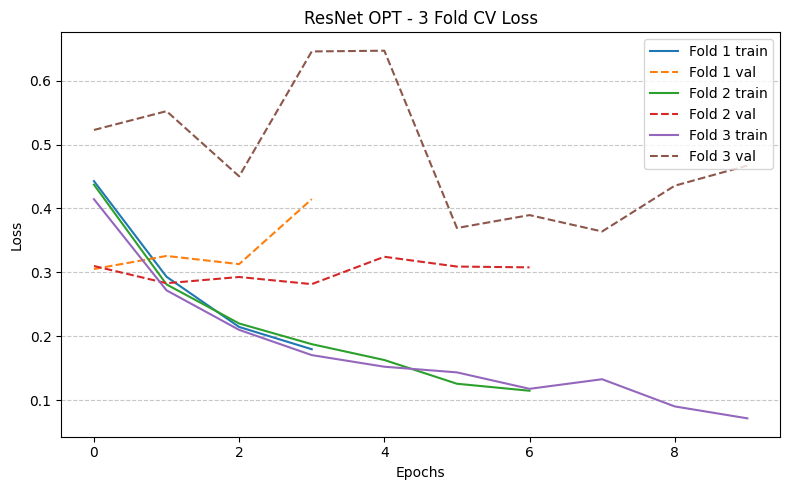

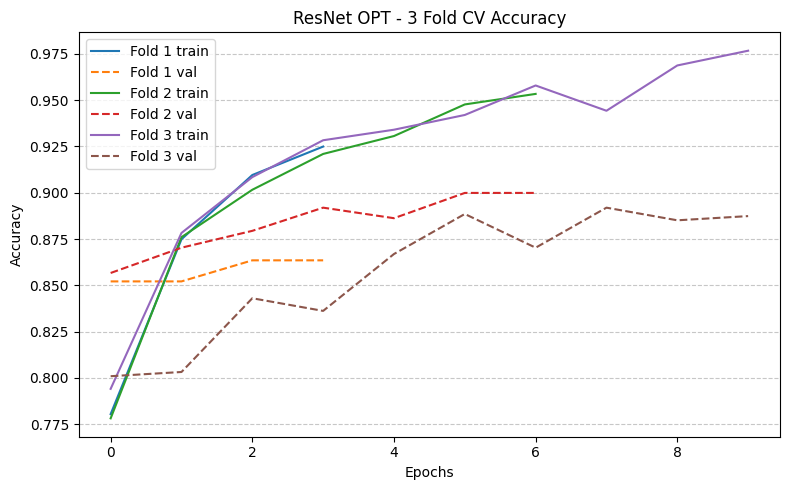

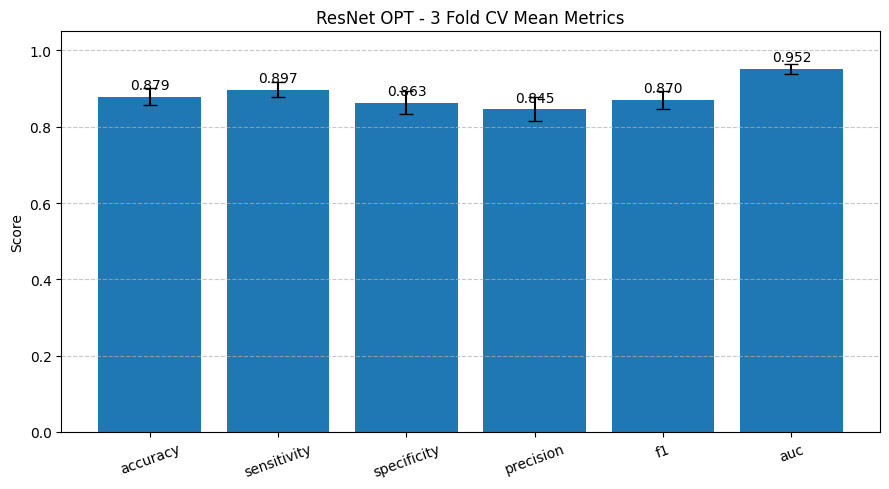


All histories saved to:
/content/drive/MyDrive/CrossValidation/ResnetOPT/histories/resnet_3fold_all_histories.json

DONE: 3-fold cross validation completed.


In [ ]:
# PLOT LOSS PER FOLD
plt.figure(figsize=(8, 5))

for fold in range(1, N_SPLITS + 1):
    h = history_dict.get(f"fold_{fold}", {})
    if not h:
        print(f"Fold {fold}: history vuota")
        continue

    if "loss" in h and len(h["loss"]) > 0:
        plt.plot(h["loss"], label=f"Fold {fold} train")
    if "val_loss" in h and len(h["val_loss"]) > 0:
        plt.plot(h["val_loss"], linestyle="--", label=f"Fold {fold} val")

plt.title("ResNet OPT - 3 Fold CV Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()

loss_plot_path = os.path.join(BASE_PATH, "plots", "training", "resnet_3fold_loss.png")
plt.savefig(loss_plot_path, dpi=300, bbox_inches="tight")
plt.show()
plt.close()


#plot accuracy per forld
plt.figure(figsize=(8, 5))

for fold in range(1, N_SPLITS + 1):
    h = history_dict.get(f"fold_{fold}", {})
    if not h:
        print(f"Fold {fold}: history vuota")
        continue

    if "accuracy" in h and len(h["accuracy"]) > 0:
        plt.plot(h["accuracy"], label=f"Fold {fold} train")
    if "val_accuracy" in h and len(h["val_accuracy"]) > 0:
        plt.plot(h["val_accuracy"], linestyle="--", label=f"Fold {fold} val")

plt.title("ResNet OPT - 3 Fold CV Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()

acc_plot_path = os.path.join(BASE_PATH, "plots", "training", "resnet_3fold_accuracy.png")
plt.savefig(acc_plot_path, dpi=300, bbox_inches="tight")
plt.show()
plt.close()

# PLOT MEAN METRICS

metric_names = ["accuracy", "sensitivity", "specificity", "precision", "f1", "auc"]
means = fold_results_df[metric_names].mean()
stds = fold_results_df[metric_names].std()

plt.figure(figsize=(9,5))
bars = plt.bar(metric_names, means, yerr=stds, capsize=5)

plt.title("ResNet OPT - 3 Fold CV Mean Metrics")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.xticks(rotation=20)
plt.tight_layout()

for bar, mean in zip(bars, means):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        mean + 0.02,
        f"{mean:.3f}",
        ha="center",
        fontsize=10
    )

metrics_plot_path = os.path.join(BASE_PATH, "plots", "metrics", "resnet_3fold_cv_mean_metrics.png")
plt.savefig(metrics_plot_path, dpi=300, bbox_inches="tight")
plt.show()
plt.close()

#SAVE HISTORIES COMBINED

combined_history_path = os.path.join(BASE_PATH, "histories", "resnet_3fold_all_histories.json")
with open(combined_history_path, "w") as f:
    json.dump(history_dict, f, indent=4)

print("\nAll histories saved to:")
print(combined_history_path)

print("\nDONE: 3-fold cross validation completed.")

TABELLA RIASSUNTIVA DELLE MEDIE


,model,accuracy,sensitivity,specificity,f1,auc
0,resnet,0.8786,0.8972,0.8632,0.8705,0.9516


TABELLA RIASSUNTIVA COMPLETA


,fold,accuracy,sensitivity,specificity,f1,auc
0,1,0.8521,0.8797,0.8292,0.8438,0.9371
1,2,0.8919,0.8947,0.8896,0.8826,0.9568
2,3,0.8919,0.9173,0.8708,0.8851,0.9608


/tmp/ipykernel_778/2543556992.py:129: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = ax.boxplot(


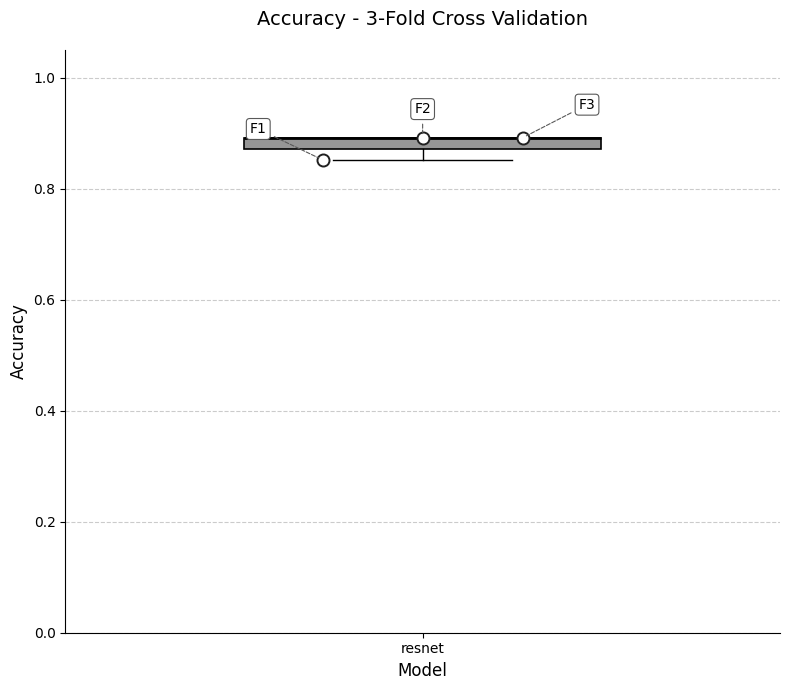

/tmp/ipykernel_778/2543556992.py:129: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = ax.boxplot(


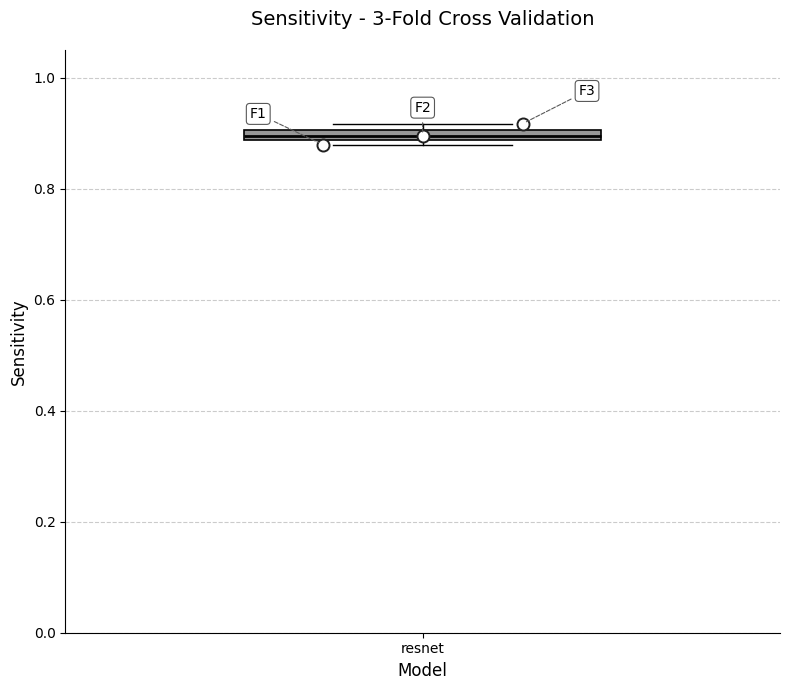

/tmp/ipykernel_778/2543556992.py:129: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = ax.boxplot(


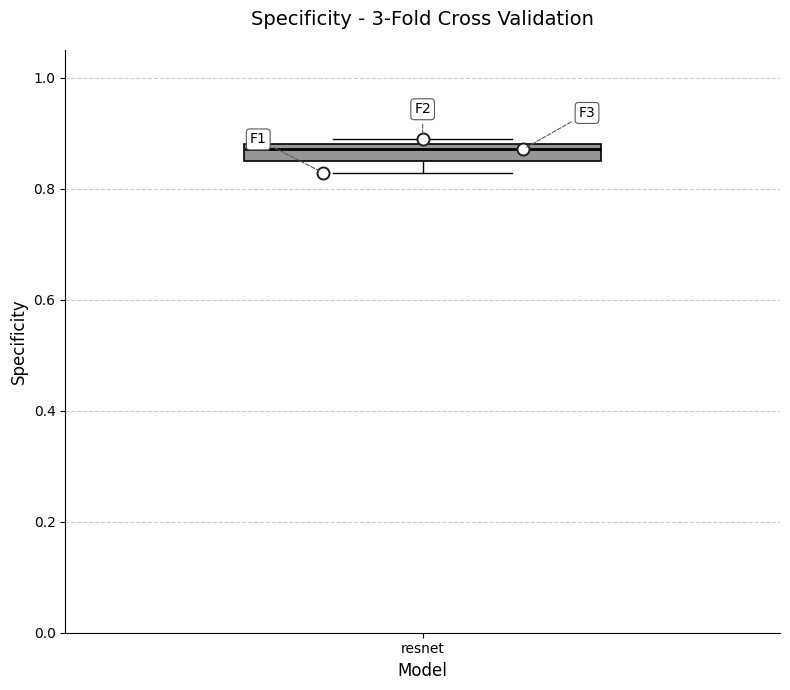

/tmp/ipykernel_778/2543556992.py:129: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = ax.boxplot(


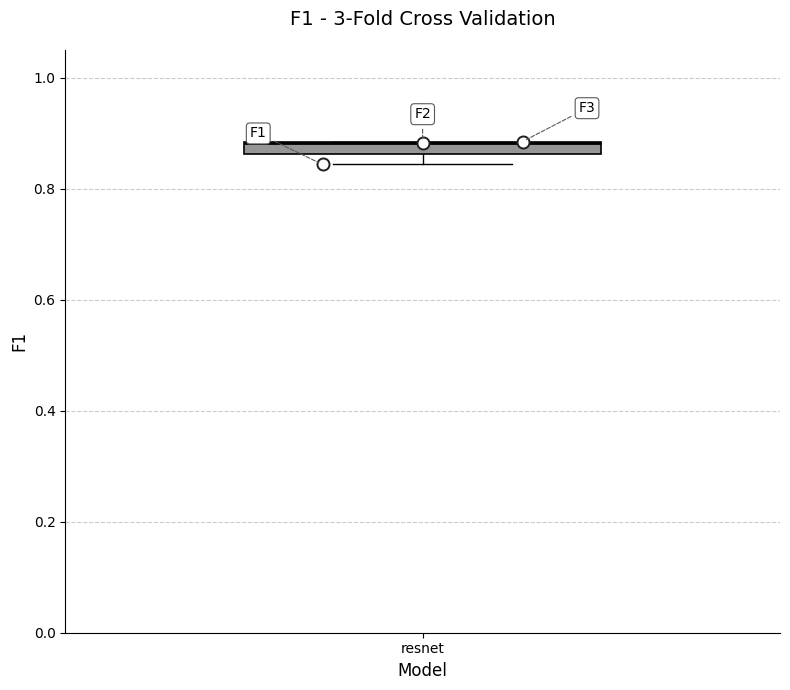

/tmp/ipykernel_778/2543556992.py:129: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = ax.boxplot(


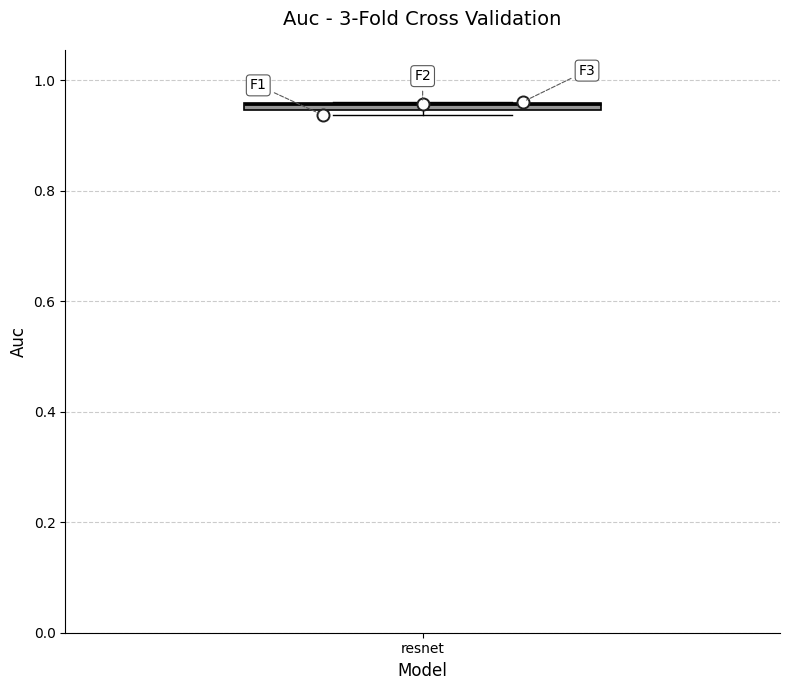

Elaborazione completata.
Grafici salvati in: /content/drive/MyDrive/CrossValidation/ResnetOPT/plots/metrics
Tabella delle medie salvata in: /content/drive/MyDrive/CrossValidation/ResnetOPT/metrics/resnet_summary_means.csv
Tabella completa salvata in: /content/drive/MyDrive/CrossValidation/ResnetOPT/metrics/resnet_complete_summary_by_fold.csv


In [4]:
# GRAFICI E TABELLE FINALI PER RESNET
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

model_name = "resnet"
metrics_path = os.path.join(BASE_PATH, "metrics")
plots_path = os.path.join(BASE_PATH, "plots", "metrics")
os.makedirs(plots_path, exist_ok=True)

metrics_to_plot = [
    "accuracy",
    "sensitivity",
    "specificity",
    "f1",
    "auc"
]

model_colors = {
    "resnet": "#969696"
}
point_color = "#202020"

# Caricamento dei risultati dei tre fold
fold_metrics_path = os.path.join(
    metrics_path,
    f"{model_name}_3fold_cv_results.csv"
)

if not os.path.exists(fold_metrics_path):
    raise FileNotFoundError(
        f"File dei risultati non trovato:\n{fold_metrics_path}"
    )

complete_df = pd.read_csv(fold_metrics_path)

# Normalizzazione del nome della colonna fold
fold_column_candidates = ["fold", "Fold", "fold_id", "Fold_ID"]

existing_fold_column = next(
    (
        column for column in fold_column_candidates
        if column in complete_df.columns
    ),
    None
)

if existing_fold_column is None:
    raise ValueError(
        "Colonna fold non trovata nel file dei risultati."
    )

if existing_fold_column != "fold":
    complete_df.rename(
        columns={existing_fold_column: "fold"},
        inplace=True
    )

# Controllo delle metriche
missing_metrics = [
    metric for metric in metrics_to_plot
    if metric not in complete_df.columns
]

if missing_metrics:
    raise ValueError(
        f"Metriche mancanti nel file CSV: {missing_metrics}"
    )

complete_df = complete_df.sort_values(
    by="fold"
).reset_index(drop=True)

# TABELLA DELLE MEDIE

mean_table = complete_df[
    metrics_to_plot
].mean().to_frame().T

mean_table.insert(0, "model", model_name)
mean_table = mean_table.round(4)

mean_table_path = os.path.join(
    metrics_path,
    f"{model_name}_summary_means.csv"
)

mean_table.to_csv(mean_table_path, index=False)

print("TABELLA RIASSUNTIVA DELLE MEDIE")
display(mean_table)

# TABELLA COMPLETA DEI FOLD

complete_table = complete_df[
    ["fold"] + metrics_to_plot
].copy()

complete_table[metrics_to_plot] = (
    complete_table[metrics_to_plot].round(4)
)

complete_table_path = os.path.join(
    metrics_path,
    f"{model_name}_complete_summary_by_fold.csv"
)

complete_table.to_csv(
    complete_table_path,
    index=False
)

print("TABELLA RIASSUNTIVA COMPLETA")
display(complete_table)



# BOXPLOT DEI TRE FOLD

rng = np.random.default_rng(42)

for metric in metrics_to_plot:

    fig, ax = plt.subplots(figsize=(8, 7))

    fold_values = complete_df[metric].dropna().to_numpy()

    box = ax.boxplot(
        [fold_values],
        labels=[model_name],
        patch_artist=True,
        widths=0.5,
        showfliers=False,
        medianprops={
            "color": "black",
            "linewidth": 2
        },
        whiskerprops={
            "color": "black",
            "linewidth": 1
        },
        capprops={
            "color": "black",
            "linewidth": 1
        },
        boxprops={
            "edgecolor": "black",
            "linewidth": 1.2
        }
    )

    box["boxes"][0].set_facecolor(model_colors[model_name])
    box["boxes"][0].set_alpha(1)

    # Punti distribuiti orizzontalmente
    jitter = np.linspace(
        -0.14,
        0.14,
        len(fold_values)
    )

    x_points = 1 + jitter

    ax.scatter(
        x_points,
        fold_values,
        color="white",
        edgecolor=point_color,
        linewidth=1.4,
        s=75,
        zorder=5
    )

    # Posizioni verticali delle etichette
    y_min = np.min(fold_values)
    y_max = np.max(fold_values)
    value_range = max(y_max - y_min, 0.03)

    vertical_offsets = np.array([
        0.20,
        0.10,
        0.30
    ]) * value_range + 0.035

    horizontal_offsets = [-0.23, 0.0, 0.23]

    for i, (x_point, value, (_, row)) in enumerate(
        zip(
            x_points,
            fold_values,
            complete_df.iterrows()
        )
    ):

        x_text = 1 + horizontal_offsets[i % 3]
        y_text = value + vertical_offsets[i % 3]

        ax.annotate(
            f"F{int(row['fold'])}",
            xy=(x_point, value),
            xytext=(x_text, y_text),
            ha="center",
            va="bottom",
            fontsize=10,
            bbox=dict(
                boxstyle="round,pad=0.25",
                facecolor="white",
                edgecolor="0.35",
                linewidth=0.8
            ),
            arrowprops=dict(
                arrowstyle="-",
                color="0.35",
                linewidth=0.8,
                linestyle="--",
                shrinkA=3,
                shrinkB=3
            ),
            zorder=6
        )

    ax.set_title(
        f"{metric.capitalize()} - 3-Fold Cross Validation",
        fontsize=14,
        pad=18
    )

    ax.set_xlabel("Model", fontsize=12)
    ax.set_ylabel(metric.capitalize(), fontsize=12)

    # Spazio sufficiente per le etichette
    upper_limit = max(
        1.05,
        np.max(fold_values) + np.max(vertical_offsets) + 0.05
    )

    ax.set_ylim(0, min(1.30, upper_limit))

    ax.grid(
        axis="y",
        linestyle="--",
        color="0.75",
        alpha=0.8
    )

    ax.set_axisbelow(True)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    plt.tight_layout()

    boxplot_path = os.path.join(
        plots_path,
        f"{metric}_cv_boxplot_with_folds.png"
    )

    plt.savefig(
        boxplot_path,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()
    plt.close()

print("Elaborazione completata.")
print(f"Grafici salvati in: {plots_path}")
print(f"Tabella delle medie salvata in: {mean_table_path}")
print(f"Tabella completa salvata in: {complete_table_path}")